# SmeshBot benchmark + MLflow logging

Benchmarks `agents.smesh_bot.SmeshBot` (the rule-based AI used as a training
opponent) against a few baseline brains over many headless matches, and logs the
results to MLflow so changes to its difficulty parameters can be compared across
revisions.

Per matchup, this tracks:
- **win rate** (player 0 = SmeshBot)
- **average match length** (frames)
- **average damage dealt / taken** per match
- **self-KO rate** — fraction of matches where SmeshBot lost a stock without being
  hit in the previous `SELF_KO_WINDOW` frames (i.e. it walked/fell to its death on
  its own). This is the failure mode the border-edge fix addressed, so it doubles
  as a regression check.

Drives `Match` directly (headless, no Gym env / Pygame window needed).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from smeshlite.core.match import Match, MatchConfig
from agents.smesh_bot import SmeshBot
from agents.chaser_bot import ChaserBot
from agents.random_bot import RandomBot

## Match runner

Plays one full headless match between two brains and extracts summary stats.
"Self-KO" = a stock lost without a recorded `damage_event` against that player in
the previous `SELF_KO_WINDOW` frames.

In [2]:
SELF_KO_WINDOW = 30  # frames (~0.5s at 30fps)


def run_match(brain_a, brain_b, max_frames=7200):
    """Play one headless match. brain_a/brain_b are CharacterBrain factories (no-arg callables)."""
    m = Match(MatchConfig(time_limit=max_frames))
    m.reset(n_players=2)
    m.set_player_brain(0, brain_a())
    m.set_player_brain(1, brain_b())

    dmg_dealt = [0.0, 0.0]
    last_hit_frame = [-SELF_KO_WINDOW - 1, -SELF_KO_WINDOW - 1]
    kos_against = [0, 0]
    self_kos = [0, 0]
    prev_stocks = [c.stocks for c in m.characters]

    while not m.done:
        info = m.tick()
        for ev in info.get("damage_events", []):
            dmg_dealt[ev["attacker"]] += ev["damage"]
            last_hit_frame[ev["target"]] = m.frame

        for i, c in enumerate(m.characters):
            if c.stocks < prev_stocks[i]:
                kos_against[i] += 1
                if m.frame - last_hit_frame[i] > SELF_KO_WINDOW:
                    self_kos[i] += 1
                prev_stocks[i] = c.stocks

    return {
        "winner": m.winner,
        "frames": m.frame,
        "p0_dmg_dealt": dmg_dealt[0],
        "p1_dmg_dealt": dmg_dealt[1],
        "p0_kos_against": kos_against[0],
        "p1_kos_against": kos_against[1],
        "p0_self_kos": self_kos[0],
        "p1_self_kos": self_kos[1],
    }

## Run the benchmark

SmeshBot (player 0) vs. each baseline (player 1), `N_MATCHES` matches per matchup.
Each match re-seeds Python's `random` module for reproducibility.

In [3]:
import random

N_MATCHES = 30

MATCHUPS = {
    "vs RandomBot": RandomBot,
    "vs ChaserBot": ChaserBot,
    "vs SmeshBot (mirror)": SmeshBot,
}

rows = []
for name, opponent_cls in MATCHUPS.items():
    for seed in range(N_MATCHES):
        random.seed(seed)
        result = run_match(SmeshBot, opponent_cls)
        result["matchup"] = name
        result["seed"] = seed
        rows.append(result)

df = pd.DataFrame(rows)
df.head()

,winner,frames,p0_dmg_dealt,p1_dmg_dealt,p0_kos_against,p1_kos_against,p0_self_kos,p1_self_kos,matchup,seed
0,0,5843,125.0,510.0,0,3,0,3,vs RandomBot,0
1,0,2595,59.0,201.0,0,3,0,3,vs RandomBot,1
2,0,1913,52.0,145.0,0,3,0,3,vs RandomBot,2
3,0,2384,82.0,102.0,0,3,0,3,vs RandomBot,3
4,0,3522,144.0,336.0,0,3,0,3,vs RandomBot,4


## Summary per matchup

In [4]:
summary = df.groupby("matchup", sort=False).agg(
    win_rate=("winner", lambda w: (w == 0).mean()),
    avg_frames=("frames", "mean"),
    avg_dmg_dealt=("p0_dmg_dealt", "mean"),
    avg_dmg_taken=("p1_dmg_dealt", "mean"),
    avg_kos=("p1_kos_against", "mean"),
    avg_deaths=("p0_kos_against", "mean"),
    self_ko_rate=("p0_self_kos", lambda s: (s > 0).mean()),
).reset_index()
summary

,matchup,win_rate,avg_frames,avg_dmg_dealt,avg_dmg_taken,avg_kos,avg_deaths,self_ko_rate
0,vs RandomBot,1.000000,2731.066667,89.866667,267.933333,3.000000,0.000000,0.000000
1,vs ChaserBot,0.966667,6044.600000,528.366667,93.266667,1.933333,0.133333,0.100000
2,vs SmeshBot (mirror),0.600000,6580.833333,748.133333,673.066667,2.100000,1.700000,0.966667


## Log to MLflow

Requires `pip install mlflow` (see the `bench` extra in `pyproject.toml`). Each
matchup is logged as a nested run under a parent `smesh_bot_benchmark` run, so
results from different code revisions / parameter sets can be compared in the
MLflow UI (`mlflow ui`).

In [7]:
import inspect
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("smesh_bot_benchmark")

# SmeshBot's difficulty constants, as currently configured (its __init__ defaults).
_sig = inspect.signature(SmeshBot.__init__)
_bot = SmeshBot()
smesh_bot_params = {name: getattr(_bot, name) for name in _sig.parameters if name != "self"}

with mlflow.start_run(run_name=f"benchmark_{time.strftime('%Y%m%d_%H%M%S')}"):
    mlflow.log_param("n_matches_per_matchup", N_MATCHES)
    mlflow.log_param("self_ko_window_frames", SELF_KO_WINDOW)
    for k, v in smesh_bot_params.items():
        mlflow.log_param(f"smesh_bot.{k}", v)

    for _, row in summary.iterrows():
        with mlflow.start_run(run_name=row["matchup"], nested=True):
            mlflow.log_param("matchup", row["matchup"])
            for metric in ("win_rate", "avg_frames", "avg_dmg_dealt", "avg_dmg_taken",
                           "avg_kos", "avg_deaths", "self_ko_rate"):
                mlflow.log_metric(metric, row[metric])

print("Logged to MLflow. Run `mlflow ui` and open http://127.0.0.1:5000 to inspect.")

🏃 View run vs RandomBot at: http://localhost:5000/#/experiments/1/runs/34e03e9819be46aca9f0b9184b3e9e1a
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run vs ChaserBot at: http://localhost:5000/#/experiments/1/runs/e44f6c346ba040a28bee190254a4ede9
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run vs SmeshBot (mirror) at: http://localhost:5000/#/experiments/1/runs/8d823b19b5f14892ae6e1725d1a9a1fe
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run benchmark_20260611_182457 at: http://localhost:5000/#/experiments/1/runs/aef622c0f5ea429b9749809b44690259
🧪 View experiment at: http://localhost:5000/#/experiments/1
Logged to MLflow. Run `mlflow ui` and open http://127.0.0.1:5000 to inspect.


## Visualize

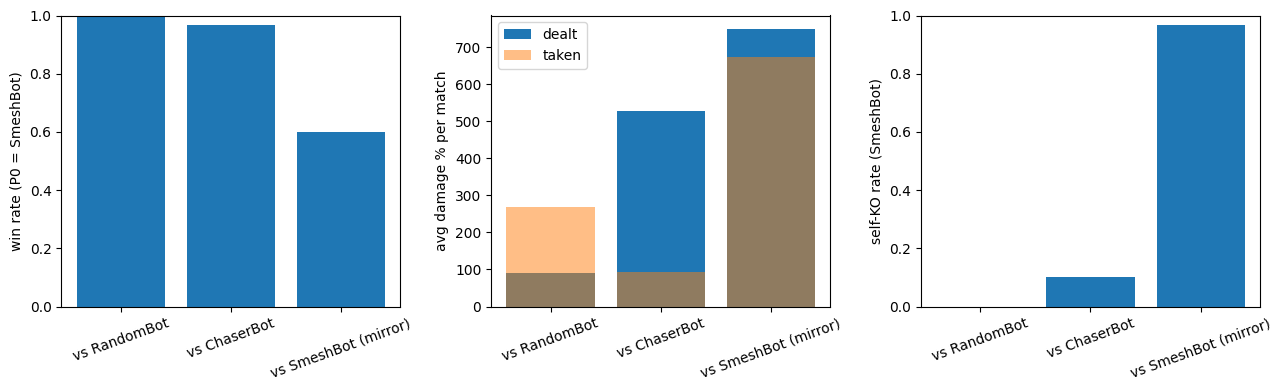

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(summary["matchup"], summary["win_rate"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("win rate (P0 = SmeshBot)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary["matchup"], summary["avg_dmg_dealt"], label="dealt")
axes[1].bar(summary["matchup"], summary["avg_dmg_taken"], alpha=0.5, label="taken")
axes[1].set_ylabel("avg damage % per match")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

axes[2].bar(summary["matchup"], summary["self_ko_rate"])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("self-KO rate (SmeshBot)")
axes[2].tick_params(axis="x", rotation=20)

fig.tight_layout()